In [3]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

output_dir = Path('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/output/Soubre_Test_Tile')

# Check what's available so far
tifs = sorted(output_dir.glob('*_2023_t*_embed.tif'))
print(f"Found {len(tifs)} completed thresholds:")
for tif in tifs:
    print(f"  {tif.name}  ({tif.stat().st_size / 1e6:.0f} MB)")

Mounted at /content/drive
Found 17 completed thresholds:
  TESSERA_Soubre_Test_Tile_2023_t005_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t015_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t020_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t025_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t030_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t035_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t040_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t045_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t050_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t055_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t060_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t065_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t070_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t075_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t080_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023_t085_embed.tif  (128 MB)
  TESSERA_Soubre_Test_Tile_2023

In [ ]:
import rasterio
import numpy as np
from pathlib import Path

#output_dir = Path('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/output/Soubre_Test_Tile')

tifs = sorted(output_dir.glob('*_2023_t*_embed.tif'))

# Load per-band means for each threshold
band_means = {}
for tif in tifs:
    threshold = tif.stem.split('_t')[1].split('_')[0]
    with rasterio.open(tif) as src:
        data = src.read().astype(np.float32)  # (128, 500, 500)
    band_means[threshold] = data.mean(axis=(1, 2))  # (128,) — one mean per band

# Compare each threshold against t020 baseline
baseline = band_means['020']
print(f"{'Threshold':>10}  {'Mean abs diff':>14}  {'Max abs diff':>13}  {'Corr with t020':>15}")
print("-" * 60)
for threshold, means in band_means.items():
    diff = np.abs(means - baseline)
    corr = np.corrcoef(means, baseline)[0, 1]
    print(f"{threshold:>9}%  {diff.mean():>14.6f}  {diff.max():>13.6f}  {corr:>15.6f}")

 Threshold   Mean abs diff   Max abs diff   Corr with t020
------------------------------------------------------------
      005%        0.001536       0.005661         1.000000
      015%        1.395882       6.475095         0.973231
      020%        0.000000       0.000000         1.000000
      025%        0.433062       1.596423         0.997263
      030%        0.432626       1.594783         0.997267
      035%        0.488876       1.708938         0.996322
      040%        0.709327       2.323873         0.992459
      045%        0.966054       3.462510         0.985397
      050%        1.083977       3.913468         0.982121
      055%        1.117853       3.935291         0.981048
      060%        1.183505       4.184428         0.978573
      065%        1.212047       4.358397         0.977494
      070%        1.400409       4.973277         0.970450
      075%        1.414221       4.997089         0.969815
      080%        1.443625       5.021502         0.96

In [ ]:
# Sample random pixels and compare distributions
baseline_path = output_dir / 'TESSERA_Soubre_Test_Tile_2023_t020_embed.tif'
with rasterio.open(baseline_path) as src:
    baseline = src.read().astype(np.float32)  # (128, 500, 500)

print(f"{'Threshold':>10}  {'Mean px diff':>13}  {'Std px diff':>12}  {'% pixels > 0.1':>15}")
print("-" * 60)
for tif in tifs:
    threshold = tif.stem.split('_t')[1].split('_')[0]
    if threshold == '020':
        continue
    with rasterio.open(tif) as src:
        data = src.read().astype(np.float32)
    diff = np.abs(data - baseline)
    pct_changed = (diff > 0.1).mean() * 100
    print(f"{threshold:>9}%  {diff.mean():>13.6f}  {diff.std():>12.6f}  {pct_changed:>14.2f}%")

 Threshold   Mean px diff   Std px diff   % pixels > 0.1
------------------------------------------------------------
      005%       0.637953      0.537824           89.22%
      015%       2.316690      1.890360           97.11%
      025%       0.994917      0.816491           93.20%
      030%       0.994937      0.816950           93.20%
      035%       1.190382      0.965774           94.36%
      040%       1.478714      1.174791           95.53%
      045%       1.762896      1.385308           96.29%
      050%       1.916549      1.507715           96.58%
      055%       1.949515      1.530862           96.64%
      060%       2.059032      1.614922           96.82%
      065%       2.087277      1.635133           96.87%
      070%       2.271811      1.777215           97.13%
      075%       2.292873      1.793949           97.15%
      080%       2.328713      1.819931           97.20%
      085%       2.332572      1.822663           97.20%
      090%       2.382625  

In [ ]:
# If you have two runs at t020, compare them
# Otherwise, re-run inference once more at t020 and compare to the original
tif1 = output_dir / 'TESSERA_Soubre_Test_Tile_2023_t090_embed.tif'
tif2 = output_dir / 'TESSERA_Soubre_Test_Tile_2023_embed.tif'  # replace with second run

with rasterio.open(tif1) as src:
    data1 = src.read().astype(np.float32)
with rasterio.open(tif2) as src:
    data2 = src.read().astype(np.float32)

diff = np.abs(data1 - data2)
print(f"Mean px diff : {diff.mean():.6f}")
print(f"Std px diff  : {diff.std():.6f}")
print(f"% px > 0.1   : {(diff > 0.1).mean()*100:.2f}%")

Mean px diff : 2.382213
Std px diff  : 1.860268
% px > 0.1   : 97.27%


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def stretch(arr):
    p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
    return np.clip((arr - p2) / (p98 - p2), 0, 1)

BANDS    = [10, 50, 100]  # R, G, B
tif_t020 = output_dir / 'TESSERA_Soubre_Test_Tile_2023_t090_embed.tif'
tif_t080 = output_dir / 'TESSERA_Soubre_Test_Tile_2023_embed.tif'

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (label, tif_path) in zip(axes, [('t020 (4 scenes)', tif_t020),
                                          ('t090 (44 scenes)', tif_t080)]):
    with rasterio.open(tif_path) as src:
        rgb = np.stack([stretch(src.read(b).astype(np.float32)) for b in BANDS], axis=-1)
    ax.imshow(rgb)
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('TESSERA embedding comparison: t020 vs t080\nRGB = Bands 10, 50, 100', fontsize=12)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(tif_t020) as src:
    data_t020 = np.stack([src.read(b).astype(np.float32) for b in BANDS], axis=-1)
with rasterio.open(tif_t080) as src:
    data_t080 = np.stack([src.read(b).astype(np.float32) for b in BANDS], axis=-1)

diff = data_t080 - data_t020

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (ax, band) in enumerate(zip(axes, BANDS)):
    im = ax.imshow(diff[:, :, i], cmap='RdBu_r',
                   vmin=np.percentile(diff[:, :, i], 2),
                   vmax=np.percentile(diff[:, :, i], 98))
    ax.set_title(f'Band {band}  (t080 − t020)', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Difference: t080 − t020\nRed = t080 higher, Blue = t020 higher', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nDifference statistics per band:")
for i, band in enumerate(BANDS):
    d = diff[:, :, i]
    print(f"  Band {band:>3}:  mean={d.mean():>8.4f}  std={d.std():>8.4f}  "
          f"min={d.min():>8.4f}  max={d.max():>8.4f}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from collections import defaultdict

# Raw data from query table
threshold_dates = {
    5:  ['2023-01-02', '2023-01-07', '2023-12-18', '2023-12-23'],
    10: ['2023-01-02', '2023-01-07', '2023-12-18', '2023-12-23'],
    15: ['2023-01-02', '2023-01-07', '2023-12-18', '2023-12-23'],
    20: ['2023-01-02', '2023-01-07', '2023-04-02', '2023-05-07', '2023-12-13', '2023-12-18', '2023-12-23'],
    25: ['2023-01-02', '2023-01-07', '2023-04-02', '2023-04-27', '2023-05-07', '2023-12-13', '2023-12-18', '2023-12-23'],
    30: ['2023-01-02', '2023-01-07', '2023-04-02', '2023-04-27', '2023-05-07', '2023-12-13', '2023-12-18', '2023-12-23'],
    35: ['2023-01-02', '2023-01-07', '2023-02-06', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-07', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23'],
    40: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-02-06', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-07', '2023-05-17', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23'],
    45: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-02-06', '2023-03-08', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-07', '2023-05-17', '2023-05-22', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23'],
    50: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-02-06', '2023-02-11', '2023-03-08', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-07', '2023-05-17', '2023-05-22', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    55: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-02-06', '2023-02-11', '2023-02-16', '2023-03-08', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-07', '2023-05-17', '2023-05-22', '2023-05-27', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    60: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-02-06', '2023-02-11', '2023-02-16', '2023-03-08', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-17', '2023-05-22', '2023-05-27', '2023-11-03', '2023-11-08', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    65: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-03-08', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-17', '2023-05-22', '2023-05-27', '2023-07-06', '2023-11-03', '2023-11-08', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    70: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-01-27', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-03-08', '2023-03-18', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-22', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-17', '2023-05-22', '2023-05-27', '2023-06-16', '2023-07-06', '2023-10-09', '2023-10-29', '2023-11-03', '2023-11-08', '2023-11-23', '2023-11-28', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    75: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-01-27', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-03-08', '2023-03-13', '2023-03-18', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-22', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-17', '2023-05-22', '2023-05-27', '2023-06-16', '2023-07-01', '2023-07-06', '2023-10-09', '2023-10-29', '2023-11-03', '2023-11-08', '2023-11-13', '2023-11-23', '2023-11-28', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    80: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-01-27', '2023-02-01', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-03-08', '2023-03-13', '2023-03-18', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-22', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-12', '2023-05-17', '2023-05-22', '2023-05-27', '2023-06-16', '2023-07-01', '2023-07-06', '2023-07-11', '2023-07-16', '2023-09-19', '2023-10-09', '2023-10-29', '2023-11-03', '2023-11-08', '2023-11-13', '2023-11-18', '2023-11-23', '2023-11-28', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    85: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-01-27', '2023-02-01', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-03-08', '2023-03-13', '2023-03-18', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-12', '2023-04-22', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-12', '2023-05-17', '2023-05-22', '2023-05-27', '2023-06-16', '2023-07-01', '2023-07-06', '2023-07-11', '2023-07-16', '2023-07-21', '2023-09-19', '2023-09-29', '2023-10-09', '2023-10-19', '2023-10-29', '2023-11-03', '2023-11-08', '2023-11-13', '2023-11-18', '2023-11-23', '2023-11-28', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    90: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-01-27', '2023-02-01', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-03-03', '2023-03-08', '2023-03-13', '2023-03-18', '2023-03-23', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-12', '2023-04-22', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-12', '2023-05-17', '2023-05-22', '2023-05-27', '2023-06-16', '2023-07-01', '2023-07-06', '2023-07-11', '2023-07-16', '2023-07-21', '2023-07-26', '2023-08-30', '2023-09-04', '2023-09-19', '2023-09-29', '2023-10-09', '2023-10-19', '2023-10-29', '2023-11-03', '2023-11-08', '2023-11-13', '2023-11-18', '2023-11-23', '2023-11-28', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
    100: ['2023-01-02', '2023-01-07', '2023-01-12', '2023-01-17', '2023-01-22', '2023-01-27', '2023-02-01', '2023-02-06', '2023-02-11', '2023-02-16', '2023-02-21', '2023-02-26', '2023-03-03', '2023-03-08', '2023-03-13', '2023-03-18', '2023-03-23', '2023-03-28', '2023-04-02', '2023-04-07', '2023-04-12', '2023-04-17', '2023-04-22', '2023-04-27', '2023-05-02', '2023-05-07', '2023-05-12', '2023-05-17', '2023-05-22', '2023-05-27', '2023-06-01', '2023-06-06', '2023-06-11', '2023-06-16', '2023-06-21', '2023-06-26', '2023-07-01', '2023-07-06', '2023-07-11', '2023-07-16', '2023-07-21', '2023-07-26', '2023-07-31', '2023-08-05', '2023-08-10', '2023-08-15', '2023-08-20', '2023-08-25', '2023-08-30', '2023-09-04', '2023-09-09', '2023-09-14', '2023-09-19', '2023-09-24', '2023-09-29', '2023-10-04', '2023-10-09', '2023-10-14', '2023-10-19', '2023-10-24', '2023-10-29', '2023-11-03', '2023-11-08', '2023-11-13', '2023-11-18', '2023-11-23', '2023-11-28', '2023-12-03', '2023-12-08', '2023-12-13', '2023-12-18', '2023-12-23', '2023-12-28'],
}

# Count how many thresholds include each date
date_counts = defaultdict(int)
for threshold, dates in threshold_dates.items():
    for date in dates:
        date_counts[date] += 1

# Sort by date
date_counts = dict(sorted(date_counts.items()))

print(f"Total unique dates: {len(date_counts)}")
print(f"Max count (appears in all thresholds): {max(date_counts.values())}")
print(f"Min count (appears in only 1 threshold): {min(date_counts.values())}")

Total unique dates: 73
Max count (appears in all thresholds): 19
Min count (appears in only 1 threshold): 1


### Data for graph

In [ ]:
### Data for graph

In [ ]:
# Parse the data - ID	Run	T1	D1	C1	S1
data = """
1	15	1	02/01/2023	✓	cached
2	15	2	07/01/2023	✓	cached
3	15	3	18/12/2023	✓	cached
4	15	4	23/12/2023	✓	cached
5	20	1	02/01/2023	✓	cached
6	20	2	07/01/2023	✓	cached
7	20	3	02/04/2023	✓	cached
8	20	4	07/05/2023	✓	cached
9	20	5	13/12/2023	✓	cached
10	20	6	18/12/2023	✓	cached
11	20	7	23/12/2023	✓	cached
12	25	1	02/01/2023	✓	cached
13	25	2	07/01/2023	✓	cached
14	25	3	02/04/2023	✓	cached
15	25	4	27/04/2023	✓	cached
16	25	5	07/05/2023	✓	cached
17	25	6	13/12/2023	✓	cached
18	25	7	18/12/2023	✓	cached
19	25	8	23/12/2023	✓	cached
20	30	1	02/01/2023	✓	cached
21	30	2	07/01/2023	✓	cached
22	30	3	02/04/2023	✓	cached
23	30	4	27/04/2023	✓	cached
24	30	5	07/05/2023	✓	cached
25	30	6	13/12/2023	✓	cached
26	30	7	18/12/2023	✓	cached
27	30	8	23/12/2023	✓	cached
28	35	1	02/01/2023	✓	cached
29	35	2	07/01/2023	✓	cached
30	35	3	06/02/2023	✗	skipped
31	35	4	02/04/2023	✓	cached
32	35	5	07/04/2023	✓	cached
33	35	6	27/04/2023	✓	cached
34	35	7	07/05/2023	✓	cached
35	35	8	08/12/2023	✓	cached
36	35	9	13/12/2023	✓	cached
37	35	10	18/12/2023	✓	cached
38	35	11	23/12/2023	✓	cached
39	40	1	02/01/2023	✓	cached
40	40	2	07/01/2023	✓	cached
41	40	3	12/01/2023	✓	cached
42	40	4	06/02/2023	✗	skipped
43	40	5	02/04/2023	✓	cached
44	40	6	07/04/2023	✓	cached
45	40	7	27/04/2023	✓	cached
46	40	8	07/05/2023	✓	cached
47	40	9	17/05/2023	✓	cached
48	40	10	08/12/2023	✓	cached
49	40	11	13/12/2023	✓	cached
50	40	12	18/12/2023	✓	cached
51	40	13	23/12/2023	✓	cached
52	45	1	02/01/2023	✓	cached
53	45	2	07/01/2023	✓	cached
54	45	3	12/01/2023	✓	cached
55	45	4	17/01/2023	✓	cached
56	45	5	06/02/2023	✗	skipped
57	45	6	08/03/2023	✓	cached
58	45	7	02/04/2023	✓	cached
59	45	8	07/04/2023	✓	cached
60	45	9	27/04/2023	✓	cached
61	45	10	07/05/2023	✓	cached
62	45	11	17/05/2023	✓	cached
63	45	12	22/05/2023	✓	cached
64	45	13	08/12/2023	✓	cached
65	45	14	13/12/2023	✓	cached
66	45	15	18/12/2023	✓	cached
67	45	16	23/12/2023	✓	cached
68	50	1	02/01/2023	✓	cached
69	50	2	07/01/2023	✓	cached
70	50	3	12/01/2023	✓	cached
71	50	4	17/01/2023	✓	cached
72	50	5	06/02/2023	✗	skipped
73	50	6	11/02/2023	✓	cached
74	50	7	08/03/2023	✓	cached
75	50	8	02/04/2023	✓	cached
76	50	9	07/04/2023	✓	cached
77	50	10	27/04/2023	✓	cached
78	50	11	07/05/2023	✓	cached
79	50	12	17/05/2023	✓	cached
80	50	13	22/05/2023	✓	cached
81	50	14	08/12/2023	✓	cached
82	50	15	13/12/2023	✓	cached
83	50	16	18/12/2023	✓	cached
84	50	17	23/12/2023	✓	cached
85	50	18	28/12/2023	✓	cached
86	55	1	02/01/2023	✓	cached
87	55	2	07/01/2023	✓	cached
88	55	3	12/01/2023	✓	cached
89	55	4	17/01/2023	✓	cached
90	55	5	06/02/2023	✗	skipped
91	55	6	11/02/2023	✓	cached
92	55	7	16/02/2023	✗	skipped
93	55	8	08/03/2023	✓	cached
94	55	9	28/03/2023	✓	cached
95	55	10	02/04/2023	✓	cached
96	55	11	07/04/2023	✓	cached
97	55	12	27/04/2023	✓	cached
98	55	13	07/05/2023	✓	cached
99	55	14	17/05/2023	✓	cached
100	55	15	22/05/2023	✓	cached
101	55	16	27/05/2023	✓	cached
102	55	17	08/12/2023	✓	cached
103	55	18	13/12/2023	✓	cached
104	55	19	18/12/2023	✓	cached
105	55	20	23/12/2023	✓	cached
106	55	21	28/12/2023	✓	cached
107	60	1	02/01/2023	✓	cached
108	60	2	07/01/2023	✓	cached
109	60	3	12/01/2023	✓	cached
110	60	4	17/01/2023	✓	cached
111	60	5	06/02/2023	✗	skipped
112	60	6	11/02/2023	✓	cached
113	60	7	16/02/2023	✗	skipped
114	60	8	08/03/2023	✓	cached
115	60	9	28/03/2023	✓	cached
116	60	10	02/04/2023	✓	cached
117	60	11	07/04/2023	✓	cached
118	60	12	27/04/2023	✓	cached
119	60	13	02/05/2023	✓	cached
120	60	14	07/05/2023	✓	cached
121	60	15	17/05/2023	✓	cached
122	60	16	22/05/2023	✓	cached
123	60	17	27/05/2023	✓	cached
124	60	18	03/11/2023	✓	cached
125	60	19	08/11/2023	✓	cached
126	60	20	03/12/2023	✓	cached
127	60	21	08/12/2023	✓	cached
128	60	22	13/12/2023	✓	cached
129	60	23	18/12/2023	✓	cached
130	60	24	23/12/2023	✓	cached
131	60	25	28/12/2023	✓	cached
132	65	1	02/01/2023	✓	cached
133	65	2	07/01/2023	✓	cached
134	65	3	12/01/2023	✓	cached
135	65	4	17/01/2023	✓	cached
136	65	5	06/02/2023	✗	skipped
137	65	6	11/02/2023	✓	cached
138	65	7	16/02/2023	✗	skipped
139	65	8	21/02/2023	✓	cached
140	65	9	08/03/2023	✓	cached
141	65	10	28/03/2023	✓	cached
142	65	11	02/04/2023	✓	cached
143	65	12	07/04/2023	✓	cached
144	65	13	27/04/2023	✓	cached
145	65	14	02/05/2023	✓	cached
146	65	15	07/05/2023	✓	cached
147	65	16	17/05/2023	✓	cached
148	65	17	22/05/2023	✓	cached
149	65	18	27/05/2023	✓	cached
150	65	19	06/07/2023	✓	cached
151	65	20	03/11/2023	✓	cached
152	65	21	08/11/2023	✓	cached
153	65	22	03/12/2023	✓	cached
154	65	23	08/12/2023	✓	cached
155	65	24	13/12/2023	✓	cached
156	65	25	18/12/2023	✓	cached
157	65	26	23/12/2023	✓	cached
158	65	27	28/12/2023	✓	cached
159	70	1	02/01/2023	✓	cached
160	70	2	07/01/2023	✓	cached
161	70	3	12/01/2023	✓	cached
162	70	4	17/01/2023	✓	cached
163	70	5	27/01/2023	✓	cached
164	70	6	06/02/2023	✗	skipped
165	70	7	11/02/2023	✓	cached
166	70	8	16/02/2023	✗	skipped
167	70	9	21/02/2023	✓	cached
168	70	10	08/03/2023	✓	cached
169	70	11	18/03/2023	✓	cached
170	70	12	28/03/2023	✓	cached
171	70	13	02/04/2023	✓	cached
172	70	14	07/04/2023	✓	cached
173	70	15	22/04/2023	✗	skipped
174	70	16	27/04/2023	✓	cached
175	70	17	02/05/2023	✓	cached
176	70	18	07/05/2023	✓	cached
177	70	19	17/05/2023	✓	cached
178	70	20	22/05/2023	✓	cached
179	70	21	27/05/2023	✓	cached
180	70	22	16/06/2023	✓	cached
181	70	23	06/07/2023	✓	cached
182	70	24	09/10/2023	✓	cached
183	70	25	29/10/2023	✓	cached
184	70	26	03/11/2023	✓	cached
185	70	27	08/11/2023	✓	cached
186	70	28	23/11/2023	✓	cached
187	70	29	28/11/2023	✓	cached
188	70	30	03/12/2023	✓	cached
189	70	31	08/12/2023	✓	cached
190	70	32	13/12/2023	✓	cached
191	70	33	18/12/2023	✓	cached
192	70	34	23/12/2023	✓	cached
193	70	35	28/12/2023	✓	cached
194	75	1	02/01/2023	✓	cached
195	75	2	07/01/2023	✓	cached
196	75	3	12/01/2023	✓	cached
197	75	4	17/01/2023	✓	cached
198	75	5	27/01/2023	✓	cached
199	75	6	06/02/2023	✗	skipped
200	75	7	11/02/2023	✓	cached
201	75	8	16/02/2023	✗	skipped
202	75	9	21/02/2023	✓	cached
203	75	10	08/03/2023	✓	cached
204	75	11	13/03/2023	✗	skipped
205	75	12	18/03/2023	✓	cached
206	75	13	28/03/2023	✓	cached
207	75	14	02/04/2023	✓	cached
208	75	15	07/04/2023	✓	cached
209	75	16	22/04/2023	✗	skipped
210	75	17	27/04/2023	✓	cached
211	75	18	02/05/2023	✓	cached
212	75	19	07/05/2023	✓	cached
213	75	20	17/05/2023	✓	cached
214	75	21	22/05/2023	✓	cached
215	75	22	27/05/2023	✓	cached
216	75	23	16/06/2023	✓	cached
217	75	24	01/07/2023	✓	cached
218	75	25	06/07/2023	✓	cached
219	75	26	09/10/2023	✓	cached
220	75	27	29/10/2023	✓	cached
221	75	28	03/11/2023	✓	cached
222	75	29	08/11/2023	✓	cached
223	75	30	13/11/2023	✓	cached
224	75	31	23/11/2023	✓	cached
225	75	32	28/11/2023	✓	cached
226	75	33	03/12/2023	✓	cached
227	75	34	08/12/2023	✓	cached
228	75	35	13/12/2023	✓	cached
229	75	36	18/12/2023	✓	cached
230	75	37	23/12/2023	✓	cached
231	75	38	28/12/2023	✓	cached
232	80	1	02/01/2023	✓	cached
233	80	2	07/01/2023	✓	cached
234	80	3	12/01/2023	✓	cached
235	80	4	17/01/2023	✓	cached
236	80	5	27/01/2023	✓	cached
237	80	6	01/02/2023	✗	skipped
238	80	7	06/02/2023	✗	skipped
239	80	8	11/02/2023	✓	cached
240	80	9	16/02/2023	✗	skipped
241	80	10	21/02/2023	✓	cached
242	80	11	08/03/2023	✓	cached
243	80	12	13/03/2023	✗	skipped
244	80	13	18/03/2023	✓	cached
245	80	14	28/03/2023	✓	cached
246	80	15	02/04/2023	✓	cached
247	80	16	07/04/2023	✓	cached
248	80	17	22/04/2023	✗	skipped
249	80	18	27/04/2023	✓	cached
250	80	19	02/05/2023	✓	cached
251	80	20	07/05/2023	✓	cached
252	80	21	12/05/2023	✗	skipped
253	80	22	17/05/2023	✓	cached
254	80	23	22/05/2023	✓	cached
255	80	24	27/05/2023	✓	cached
256	80	25	16/06/2023	✓	cached
257	80	26	01/07/2023	✓	cached
258	80	27	06/07/2023	✓	cached
259	80	28	11/07/2023	✓	cached
260	80	29	16/07/2023	✓	cached
261	80	30	19/09/2023	✓	cached
262	80	31	09/10/2023	✓	cached
263	80	32	29/10/2023	✓	cached
264	80	33	03/11/2023	✓	cached
265	80	34	08/11/2023	✓	cached
266	80	35	13/11/2023	✓	cached
267	80	36	18/11/2023	✓	cached
268	80	37	23/11/2023	✓	cached
269	80	38	28/11/2023	✓	cached
270	80	39	03/12/2023	✓	cached
271	80	40	08/12/2023	✓	cached
272	80	41	13/12/2023	✓	cached
273	80	42	18/12/2023	✓	cached
274	80	43	23/12/2023	✓	cached
275	80	44	28/12/2023	✓	cached
276	85	1	02/01/2023	✓	cached
277	85	2	07/01/2023	✓	cached
278	85	3	12/01/2023	✓	cached
279	85	4	17/01/2023	✓	cached
280	85	5	27/01/2023	✓	cached
281	85	6	01/02/2023	✗	skipped
282	85	7	06/02/2023	✗	skipped
283	85	8	11/02/2023	✓	cached
284	85	9	16/02/2023	✗	skipped
285	85	10	21/02/2023	✓	cached
286	85	11	08/03/2023	✓	cached
287	85	12	13/03/2023	✗	skipped
288	85	13	18/03/2023	✓	cached
289	85	14	28/03/2023	✓	cached
290	85	15	02/04/2023	✓	cached
291	85	16	07/04/2023	✓	cached
292	85	17	12/04/2023	✗	skipped
293	85	18	22/04/2023	✗	skipped
294	85	19	27/04/2023	✓	cached
295	85	20	02/05/2023	✓	cached
296	85	21	07/05/2023	✓	cached
297	85	22	12/05/2023	✗	skipped
298	85	23	17/05/2023	✓	cached
299	85	24	22/05/2023	✓	cached
300	85	25	27/05/2023	✓	cached
301	85	26	16/06/2023	✓	cached
302	85	27	01/07/2023	✓	cached
303	85	28	06/07/2023	✓	cached
304	85	29	11/07/2023	✓	cached
305	85	30	16/07/2023	✓	cached
306	85	31	21/07/2023	✗	skipped
307	85	32	19/09/2023	✓	cached
308	85	33	29/09/2023	✓	cached
309	85	34	09/10/2023	✓	cached
310	85	35	19/10/2023	✗	skipped
311	85	36	29/10/2023	✓	cached
312	85	37	03/11/2023	✓	cached
313	85	38	08/11/2023	✓	cached
314	85	39	13/11/2023	✓	cached
315	85	40	18/11/2023	✓	cached
316	85	41	23/11/2023	✓	cached
317	85	42	28/11/2023	✓	cached
318	85	43	03/12/2023	✓	cached
319	85	44	08/12/2023	✓	cached
320	85	45	13/12/2023	✓	cached
321	85	46	18/12/2023	✓	cached
322	85	47	23/12/2023	✓	cached
323	85	48	28/12/2023	✓	cached
324	90	1	02/01/2023	✓	cached
325	90	2	07/01/2023	✓	cached
326	90	3	12/01/2023	✓	cached
327	90	4	17/01/2023	✓	cached
328	90	5	27/01/2023	✓	cached
329	90	6	01/02/2023	✗	skipped
330	90	7	06/02/2023	✗	skipped
331	90	8	11/02/2023	✓	cached
332	90	9	16/02/2023	✗	skipped
333	90	10	21/02/2023	✓	cached
334	90	11	03/03/2023	✗	skipped
335	90	12	08/03/2023	✓	cached
336	90	13	13/03/2023	✗	skipped
337	90	14	18/03/2023	✓	cached
338	90	15	23/03/2023	✗	skipped
339	90	16	28/03/2023	✓	cached
340	90	17	02/04/2023	✓	cached
341	90	18	07/04/2023	✓	cached
342	90	19	12/04/2023	✗	skipped
343	90	20	22/04/2023	✗	skipped
344	90	21	27/04/2023	✓	cached
345	90	22	02/05/2023	✓	cached
346	90	23	07/05/2023	✓	cached
347	90	24	12/05/2023	✗	skipped
348	90	25	17/05/2023	✓	cached
349	90	26	22/05/2023	✓	cached
350	90	27	27/05/2023	✓	cached
351	90	28	16/06/2023	✓	cached
352	90	29	01/07/2023	✓	cached
353	90	30	06/07/2023	✓	cached
354	90	31	11/07/2023	✓	cached
355	90	32	16/07/2023	✓	cached
356	90	33	21/07/2023	✗	skipped
357	90	34	26/07/2023	✓	cached
358	90	35	30/08/2023	✗	skipped
359	90	36	04/09/2023	✓	cached
360	90	37	19/09/2023	✓	cached
361	90	38	29/09/2023	✓	cached
362	90	39	09/10/2023	✓	cached
363	90	40	19/10/2023	✗	skipped
364	90	41	29/10/2023	✓	cached
365	90	42	03/11/2023	✓	cached
366	90	43	08/11/2023	✓	cached
367	90	44	13/11/2023	✓	cached
368	90	45	18/11/2023	✓	cached
369	90	46	23/11/2023	✓	cached
370	90	47	28/11/2023	✓	cached
371	90	48	03/12/2023	✓	cached
372	90	49	08/12/2023	✓	cached
373	90	50	13/12/2023	✓	cached
374	90	51	18/12/2023	✓	cached
375	90	52	23/12/2023	✓	cached
376	90	53	28/12/2023	✓	cached
..."""  # paste full data here

### Graph

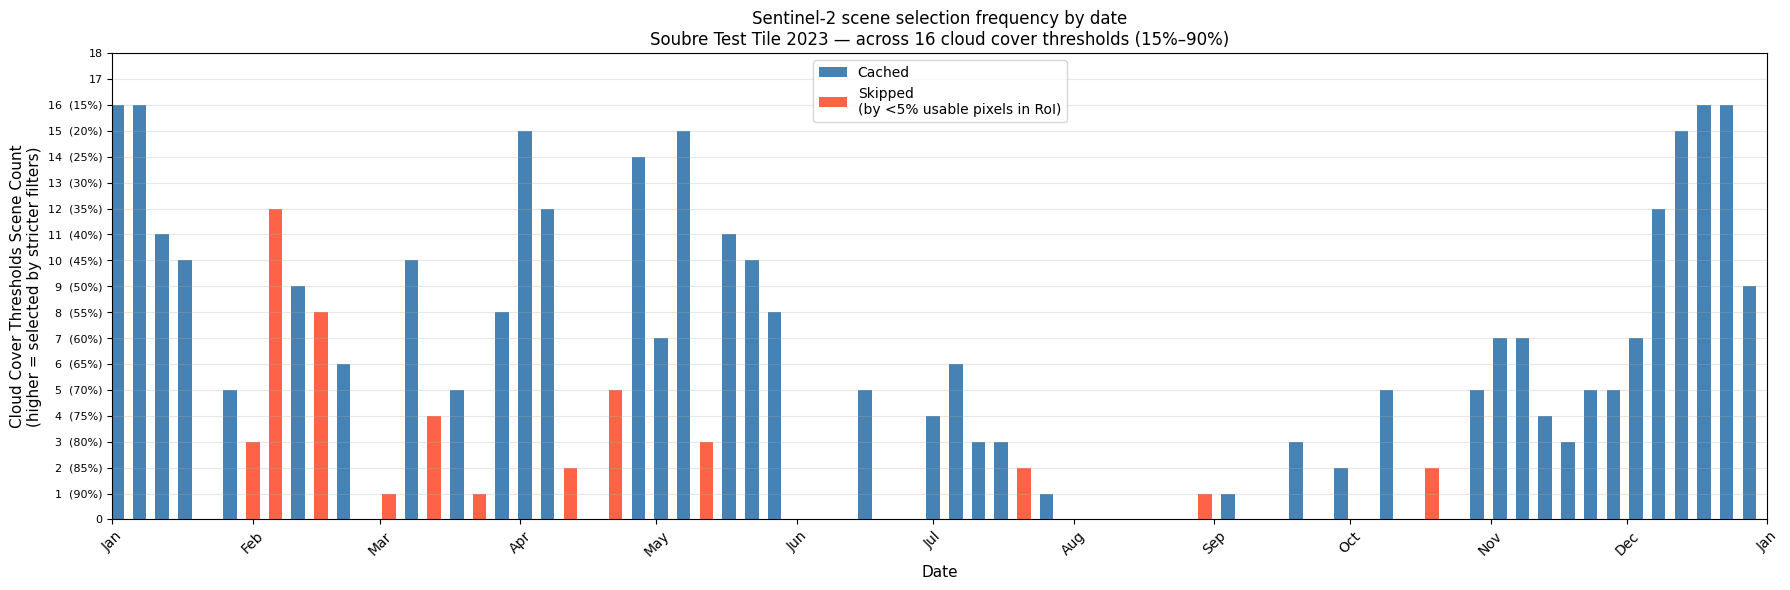

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Parse the data
rows = []
for line in data.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) == 6:
        rows.append({
            'threshold': int(parts[1]),
            'date':      datetime.strptime(parts[3], '%d/%m/%Y'),
            'result':    parts[5].strip(),
        })

df = pd.DataFrame(rows)

# Count cached and skipped per date
cached  = df[df['result'] == 'cached'].groupby('date').size()
skipped = df[df['result'] == 'skipped'].groupby('date').size()

all_dates = sorted(df['date'].unique())
cached_counts  = [cached.get(d, 0)  for d in all_dates]
skipped_counts = [skipped.get(d, 0) for d in all_dates]

# Y axis labels: count → threshold mapping
# 16 thresholds: 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90
threshold_map = {i+1: t for i, t in enumerate(range(90, 10, -5))}
yticks = list(range(0, 19, 1))
ylabels = [f"{y}  ({threshold_map[y]}%)" if y in threshold_map else str(y) for y in yticks]

# Plot
fig, ax = plt.subplots(figsize=(18, 6))

ax.bar(all_dates, cached_counts,  width=3, color='steelblue', label='Cached')
ax.bar(all_dates, skipped_counts, width=3, bottom=cached_counts, color='tomato', label='Skipped\n(by <5% usable pixels in RoI)')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cloud Cover Thresholds Scene Count\n(higher = selected by stricter filters)', fontsize=11)
ax.set_title('Sentinel-2 scene selection frequency by date\nSoubre Test Tile 2023 — across 16 cloud cover thresholds (15%–90%)', fontsize=12)

ax.set_ylim(0, 18)
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=8)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=45)

ax.legend()
ax.set_xlim(datetime(2023, 1, 1), datetime(2024, 1, 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Loading embeddings...
  ✓ t015  shape=(250000, 128)
  ✓ t020  shape=(250000, 128)
  ✓ t025  shape=(250000, 128)
  ✓ t030  shape=(250000, 128)
  ✓ t035  shape=(250000, 128)
  ✓ t040  shape=(250000, 128)
  ✓ t045  shape=(250000, 128)
  ✓ t050  shape=(250000, 128)
  ✓ t055  shape=(250000, 128)
  ✓ t060  shape=(250000, 128)
  ✓ t065  shape=(250000, 128)
  ✓ t070  shape=(250000, 128)
  ✓ t075  shape=(250000, 128)
  ✓ t080  shape=(250000, 128)
  ✓ t085  shape=(250000, 128)
  ✓ t090  shape=(250000, 128)

Computing consecutive threshold deltas...
  t015→t020:  mean_abs=2.3167  cosine=0.942339
  t020→t025:  mean_abs=0.9949  cosine=0.989016
  t025→t030:  mean_abs=0.6651  cosine=0.994940
  t030→t035:  mean_abs=0.9538  cosine=0.989806
  t035→t040:  mean_abs=1.1239  cosine=0.986033
  t040→t045:  mean_abs=1.0974  cosine=0.986650
  t045→t050:  mean_abs=1.0584  cosine=0.987011
  t050→t055:  mean_abs=0.8931  cosine=0.990852
  t055→t060:  mean_abs=1.0709  cosine=0.986925
  t060→t065:  mean_abs=0.9755  c

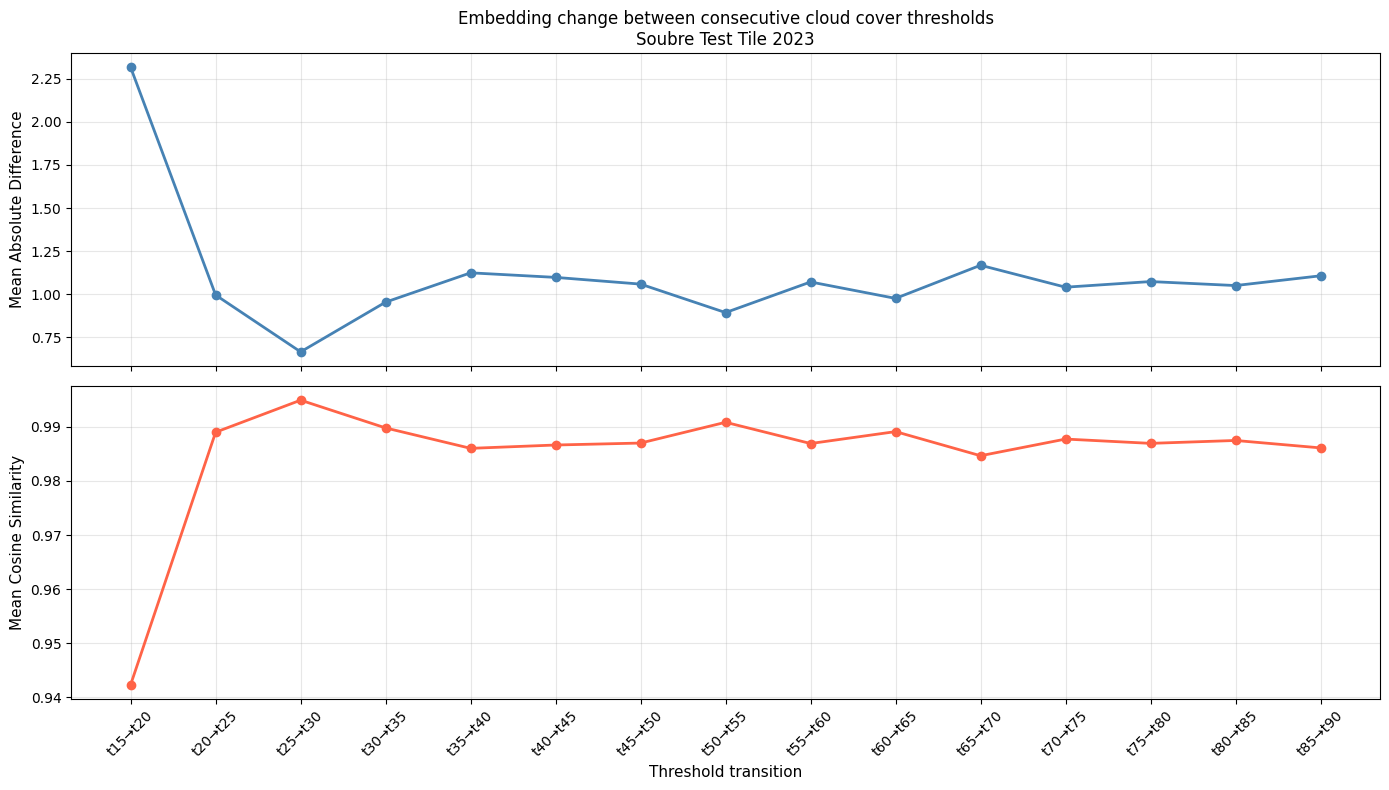

In [4]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/output/Soubre_Test_Tile')
AREA_NAME  = 'Soubre_Test_Tile'
TEST_YEAR  = 2023
THRESHOLDS = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]

# Load all embeddings
print("Loading embeddings...")
embeddings = {}
for t in THRESHOLDS:
    tif = output_dir / f'TESSERA_{AREA_NAME}_{TEST_YEAR}_t{str(t).zfill(3)}_embed.tif'
    if not tif.exists():
        print(f"  ✗ Missing: {tif.name}")
        continue
    with rasterio.open(tif) as src:
        data = src.read().astype(np.float32)  # (128, 500, 500)
    embeddings[t] = data.reshape(128, -1).T   # (250000, 128)
    print(f"  ✓ t{t:03d}  shape={embeddings[t].shape}")

# Compute consecutive deltas
print("\nComputing consecutive threshold deltas...")
thresholds_available = sorted(embeddings.keys())
deltas = []

for i in range(1, len(thresholds_available)):
    t_prev = thresholds_available[i-1]
    t_curr = thresholds_available[i]

    e_prev = embeddings[t_prev]
    e_curr = embeddings[t_curr]

    # Mean absolute difference
    mean_abs = np.abs(e_curr - e_prev).mean()

    # Cosine similarity — per pixel, then average
    dot     = (e_curr * e_prev).sum(axis=1)
    norm    = np.linalg.norm(e_curr, axis=1) * np.linalg.norm(e_prev, axis=1)
    cosine  = (dot / (norm + 1e-8)).mean()

    deltas.append({
        'from':    t_prev,
        'to':      t_curr,
        'label':   f't{t_prev}→t{t_curr}',
        'mean_abs': mean_abs,
        'cosine':   cosine,
    })
    print(f"  t{t_prev:03d}→t{t_curr:03d}:  mean_abs={mean_abs:.4f}  cosine={cosine:.6f}")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

labels     = [d['label']    for d in deltas]
mean_abs   = [d['mean_abs'] for d in deltas]
cosine     = [d['cosine']   for d in deltas]

ax1.plot(labels, mean_abs, 'o-', color='steelblue', linewidth=2, markersize=6)
ax1.set_ylabel('Mean Absolute Difference', fontsize=11)
ax1.set_title('Embedding change between consecutive cloud cover thresholds\nSoubre Test Tile 2023', fontsize=12)
ax1.grid(alpha=0.3)

ax2.plot(labels, cosine, 'o-', color='tomato', linewidth=2, markersize=6)
ax2.set_ylabel('Mean Cosine Similarity', fontsize=11)
ax2.set_xlabel('Threshold transition', fontsize=11)
ax2.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import entropy as scipy_entropy

print("Computing embedding entropy per threshold...")
entropy_per_threshold = {}

for t in thresholds_available:
    e = embeddings[t]  # (250000, 128)

    # Normalise each dimension to a probability distribution using histogram
    entropies = []
    for dim in range(e.shape[1]):  # loop over 128 dimensions
        values = e[:, dim]
        # Bin into 50 bins, get probability distribution
        counts, _ = np.histogram(values, bins=50)
        probs = counts / counts.sum()
        # Remove zero bins to avoid log(0)
        probs = probs[probs > 0]
        entropies.append(scipy_entropy(probs))

    entropy_per_threshold[t] = np.mean(entropies)
    print(f"  t{t:03d}  mean_entropy={entropy_per_threshold[t]:.4f}")

Computing embedding entropy per threshold...
  t015  mean_entropy=3.1412
  t020  mean_entropy=3.1815
  t025  mean_entropy=3.1826
  t030  mean_entropy=3.1813
  t035  mean_entropy=3.1825
  t040  mean_entropy=3.1880
  t045  mean_entropy=3.1832
  t050  mean_entropy=3.1900
  t055  mean_entropy=3.1915
  t060  mean_entropy=3.1899
  t065  mean_entropy=3.1882
  t070  mean_entropy=3.1933
  t075  mean_entropy=3.1944
  t080  mean_entropy=3.1908
  t085  mean_entropy=3.1935
  t090  mean_entropy=3.1932


In [6]:
from scipy import stats

print("Computing per-dimension entropy per threshold for significance testing...")
entropy_by_dim = {}

for t in thresholds_available:
    e = embeddings[t]  # (250000, 128)
    entropies = []
    for dim in range(e.shape[1]):
        values = e[:, dim]
        counts, _ = np.histogram(values, bins=50)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(scipy_entropy(probs))
    entropy_by_dim[t] = np.array(entropies)  # (128,)

# Test t020 vs t035 — is the difference significant?
t020_entropies = entropy_by_dim[20]
t035_entropies = entropy_by_dim[35]
t090_entropies = entropy_by_dim[90]

stat_20_35, p_20_35 = stats.wilcoxon(t020_entropies, t035_entropies)
stat_20_90, p_20_90 = stats.wilcoxon(t020_entropies, t090_entropies)
stat_35_90, p_35_90 = stats.wilcoxon(t035_entropies, t090_entropies)

print(f"\nt020 vs t035:  W={stat_20_35:.1f}  p={p_20_35:.4f}")
print(f"t020 vs t090:  W={stat_20_90:.1f}  p={p_20_90:.4f}")
print(f"t035 vs t090:  W={stat_35_90:.1f}  p={p_35_90:.4f}")

Computing per-dimension entropy per threshold for significance testing...

t020 vs t035:  W=4072.0  p=0.8941
t020 vs t090:  W=3388.0  p=0.0784
t035 vs t090:  W=3494.0  p=0.1316


Computing per-dimension entropy per threshold...


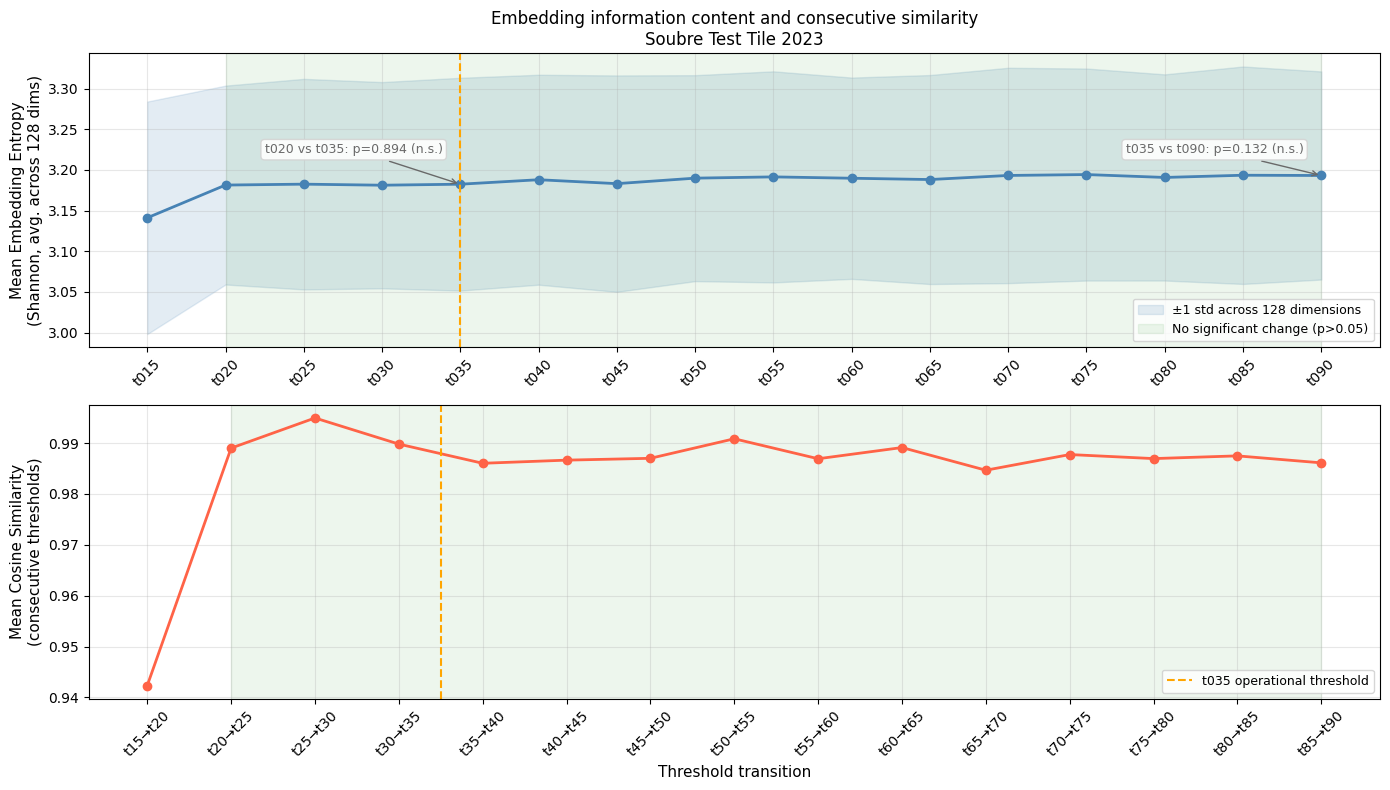

Saved.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import entropy as scipy_entropy

# --- Entropy per dimension per threshold (reuse if already computed) ---
print("Computing per-dimension entropy per threshold...")
entropy_by_dim = {}

for t in thresholds_available:
    e = embeddings[t]  # (250000, 128)
    entropies = []
    for dim in range(e.shape[1]):
        values = e[:, dim]
        counts, _ = np.histogram(values, bins=50)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(scipy_entropy(probs))
    entropy_by_dim[t] = np.array(entropies)  # (128,)

entropy_mean = [entropy_by_dim[t].mean() for t in thresholds_available]
entropy_std  = [entropy_by_dim[t].std()  for t in thresholds_available]

# --- Cosine similarity (reuse deltas from original code) ---
cosine = [d['cosine'] for d in deltas]
labels = [d['label']  for d in deltas]

# Significance annotations
stat_20_35, p_20_35 = stats.wilcoxon(entropy_by_dim[20], entropy_by_dim[35])
stat_35_90, p_35_90 = stats.wilcoxon(entropy_by_dim[35], entropy_by_dim[90])

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# --- Panel 1: Embedding entropy per threshold ---
x_entropy = list(range(len(thresholds_available)))
x_labels_entropy = [f't{t:03d}' for t in thresholds_available]

ax1.plot(x_entropy, entropy_mean, 'o-', color='steelblue', linewidth=2, markersize=6)
ax1.fill_between(x_entropy,
                 np.array(entropy_mean) - np.array(entropy_std),
                 np.array(entropy_mean) + np.array(entropy_std),
                 alpha=0.15, color='steelblue', label='±1 std across 128 dimensions')

# Shade stable zone t020–t090
idx_t20 = thresholds_available.index(20)
idx_t90 = thresholds_available.index(90)
ax1.axvspan(idx_t20, idx_t90, alpha=0.07, color='green', label='No significant change (p>0.05)')

# Get y-axis range for positioning annotations at 1/3 height
y_min, y_max = ax1.get_ylim()
y_annotation = y_min + (y_max - y_min) * 0.66

bbox_props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray',
                  alpha=0.9)

ax1.annotate(f't020 vs t035: p={p_20_35:.3f} (n.s.)',
             xy=(thresholds_available.index(35), entropy_by_dim[35].mean()),
             xytext=(thresholds_available.index(35) - 2.5, y_annotation),
             fontsize=9, color='dimgray',
             bbox=bbox_props,
             arrowprops=dict(arrowstyle='->', color='dimgray', lw=1))

ax1.annotate(f't035 vs t090: p={p_35_90:.3f} (n.s.)',
             xy=(thresholds_available.index(90), entropy_by_dim[90].mean()),
             xytext=(thresholds_available.index(90) - 2.5, y_annotation),
             fontsize=9, color='dimgray',
             bbox=bbox_props,
             arrowprops=dict(arrowstyle='->', color='dimgray', lw=1))

ax1.set_ylabel('Mean Embedding Entropy\n(Shannon, avg. across 128 dims)', fontsize=11)
ax1.set_title('Embedding information content and consecutive similarity\nSoubre Test Tile 2023', fontsize=12)
ax1.set_xticks(x_entropy)
ax1.set_xticklabels(x_labels_entropy, rotation=45)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.3)

# Mark t035 with vertical line on both panels
ax1.axvline(x=thresholds_available.index(35), color='orange',
            linestyle='--', linewidth=1.5, label='t035 operational threshold')

# --- Panel 2: Cosine similarity (consecutive transitions) ---
x_cosine = list(range(len(cosine)))
ax2.plot(x_cosine, cosine, 'o-', color='tomato', linewidth=2, markersize=6)

# Shade stable zone — from t20→t25 transition onward
ax2.axvspan(1, len(cosine) - 1, alpha=0.07, color='green')

# Mark t035 transition (t030→t035 is index 3, t035→t040 is index 4)
ax2.axvline(x=3.5, color='orange', linestyle='--', linewidth=1.5,
            label='t035 operational threshold')

ax2.set_ylabel('Mean Cosine Similarity\n(consecutive thresholds)', fontsize=11)
ax2.set_xlabel('Threshold transition', fontsize=11)
ax2.set_xticks(x_cosine)
ax2.set_xticklabels(labels, rotation=45)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / f'TESSERA_{AREA_NAME}_{TEST_YEAR}_entropy_cosine.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

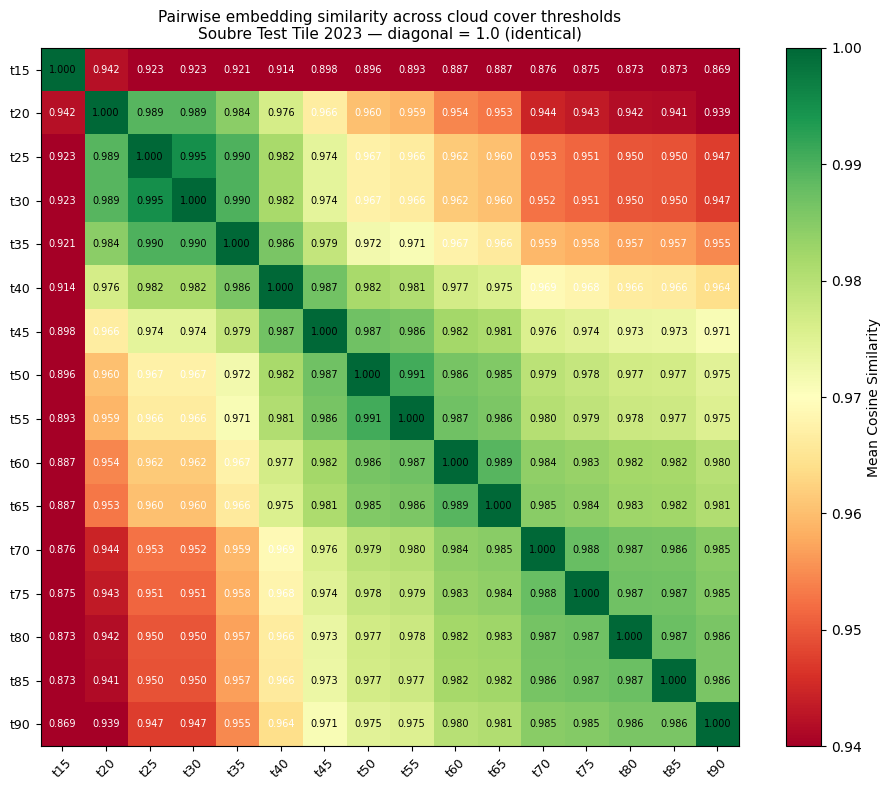

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Build 16x16 cosine similarity matrix
n = len(thresholds_available)
sim_matrix = np.zeros((n, n))

for i, t1 in enumerate(thresholds_available):
    for j, t2 in enumerate(thresholds_available):
        e1 = embeddings[t1]
        e2 = embeddings[t2]
        dot  = (e1 * e2).sum(axis=1)
        norm = np.linalg.norm(e1, axis=1) * np.linalg.norm(e2, axis=1)
        sim_matrix[i, j] = (dot / (norm + 1e-8)).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.94, vmax=1.0)

labels = [f't{t}' for t in thresholds_available]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Add values in cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}',
                ha='center', va='center', fontsize=7,
                color='black' if sim_matrix[i,j] > 0.97 else 'white')

plt.colorbar(im, ax=ax, label='Mean Cosine Similarity')
ax.set_title('Pairwise embedding similarity across cloud cover thresholds\n'
             'Soubre Test Tile 2023 — diagonal = 1.0 (identical)', fontsize=11)
plt.tight_layout()
plt.show()

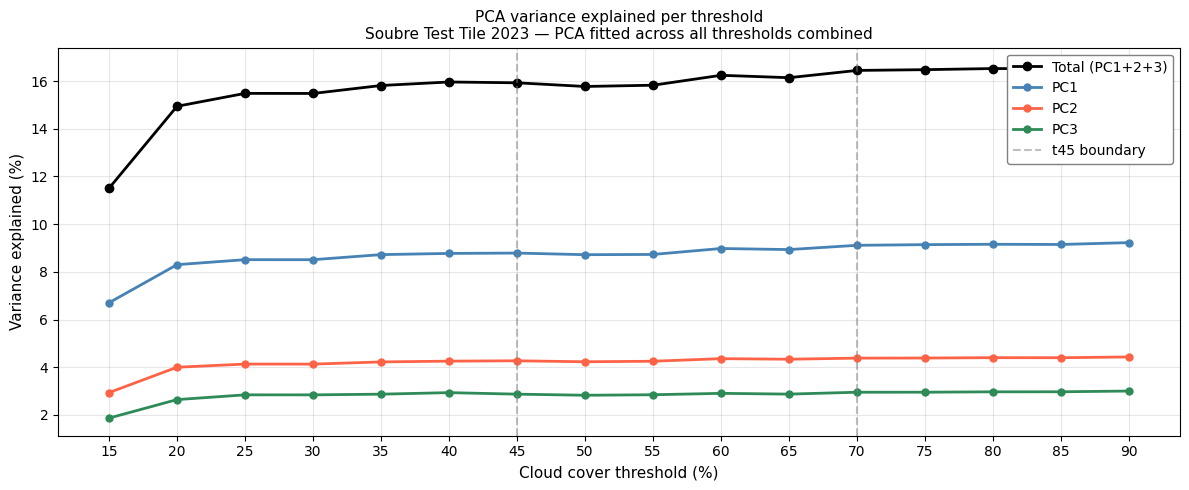

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# # Fit PCA once across all thresholds combined
# print("Fitting PCA across all thresholds combined...")
# all_pixels = np.vstack(list(embeddings.values()))  # (16*250000, 128)
# pca = PCA(n_components=3)
# pca.fit(all_pixels)
# print(f"Global variance explained by 3 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")
# print(f"Per component: {[round(v*100,2) for v in pca.explained_variance_ratio_]}")

# # Apply to each threshold and measure variance explained
# print("\nPer-threshold variance explained:")
# print(f"{'Threshold':>10}  {'PC1':>8}  {'PC2':>8}  {'PC3':>8}  {'Total':>8}")
# print("-" * 50)

# variance_results = {}
# for t in thresholds_available:
#     pixels     = embeddings[t]                          # (250000, 128)
#     projected  = pca.transform(pixels)                  # (250000, 3)
#     var_total  = pixels.var()
#     var_pc     = projected.var(axis=0)
#     explained  = var_pc / (var_total * 128) * 100       # normalised to total variance

#     variance_results[t] = {
#         'pc1':   explained[0],
#         'pc2':   explained[1],
#         'pc3':   explained[2],
#         'total': explained.sum(),
#     }
#     print(f"{t:>9}%  {explained[0]:>8.2f}  {explained[1]:>8.2f}  {explained[2]:>8.2f}  {explained.sum():>8.2f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

thresholds_plot = thresholds_available
pc1   = [variance_results[t]['pc1']   for t in thresholds_plot]
pc2   = [variance_results[t]['pc2']   for t in thresholds_plot]
pc3   = [variance_results[t]['pc3']   for t in thresholds_plot]
total = [variance_results[t]['total'] for t in thresholds_plot]

ax.plot(thresholds_plot, total, 'o-', color='black',    linewidth=2, markersize=6, label='Total (PC1+2+3)')
ax.plot(thresholds_plot, pc1,   'o-', color='steelblue',linewidth=2, markersize=5, label='PC1')
ax.plot(thresholds_plot, pc2,   'o-', color='tomato',   linewidth=2, markersize=5, label='PC2')
ax.plot(thresholds_plot, pc3,   'o-', color='seagreen', linewidth=2, markersize=5, label='PC3')

# Mark cluster boundaries
for boundary in [45, 70]:
    ax.axvline(x=boundary, color='grey', linestyle='--', alpha=0.5, label=f't{boundary} boundary' if boundary == 45 else None)

ax.set_xlabel('Cloud cover threshold (%)', fontsize=11)
ax.set_ylabel('Variance explained (%)', fontsize=11)
ax.set_title('PCA variance explained per threshold\nSoubre Test Tile 2023 — PCA fitted across all thresholds combined', fontsize=11)
ax.set_xticks(thresholds_plot)
ax.legend(loc='upper right', framealpha=1.0, facecolor='white', edgecolor='grey')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()